## Structured Output
Models can be requested to provide their response in format matching a given schema. This is helpful to ensure the output can be easily parsed and used in subsequent processing. LangChain provides multiple scehma types and methods for enforcing structured output.<br/>
Here are some of the techniques to provide structued output.

**1. Pydantic**
Pydantic models provide the richest feature set with **field validation, descriptions and nested structures**. <br/>
**2. TypedDict**

In [1]:
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
load_dotenv()

True

In [7]:
os.environ["GROQ_API_KEY"] = os.getenv("API_KEY_GROQ")
model = init_chat_model("groq:qwen/qwen3-32b")
model

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x11065f250>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x1112d8410>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'))

### Pydantic

In [3]:
### PyDantic
from pydantic import BaseModel, Field

### Schema
class Movie(BaseModel): # To make Movie a Pydantic
    title:str       = Field(description="Title of the movie.")
    year:int        = Field(description="Yea movie was released.")
    genre:str       = Field(description="Genre of the movie.")
    rating:float    = Field(description='Movie Rating')

In [9]:
structured_model = model.with_structured_output(Movie)
structured_model

RunnableBinding(bound=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x11065f250>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x1112d8410>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'Movie', 'description': '', 'parameters': {'properties': {'title': {'description': 'Title of the movie.', 'type': 'string'}, 'year': {'description': 'Yea movie was released.', 'type': 'integer'}, 'genre': {'description': 'Genre of the movie.', 'type': 'string'}, 'rating': {'description': 'Movie Rating', 'type': 'number'}}, 'required': ['title', 'year', 'genre', 'rating'], 'type': 'object'}}}], 'ls_struc

In [11]:
# Compare Model and Structured Model responses
response = model.invoke("Provide very brief information about movie Mars")
print(f"Model Response: {response.content}")

Model Response: <think>
Okay, I need to provide very brief information about the movie "Mars." Let me start by recalling what I know about it. The title is "Mars," but I should check if there's a specific year or director associated with it to avoid confusion with other movies.

First, the user mentioned "movie Mars," so I should confirm which "Mars" they're referring to. There are a few possibilities. The most likely one is the 2019 film "Mars" directed by Dennis Villeneuve, but wait, no, that's the one about Mark Watney on Mars. Wait, no, that's "The Martian." Wait, maybe there's another film titled "Mars."

Wait, I think there's a 2000 film called "Mars" directed by Joe Roth and written by James Schamus. It's based on the 1979 science fiction novel "Mars" by David W. Rintels. The movie is a three-part miniseries, but it was released as a film in some countries. Alternatively, maybe the user is referring to the 2019 documentary "Mars" produced by National Geographic and directed by R

In [13]:
response = structured_model.invoke("provide very brief information about movie Mars")
print(f"Structured Model response (PyDantic): {response}")
response

Structured Model response (PyDantic): title='Mars' year=1954 genre='Science Fiction' rating=6.5


Movie(title='Mars', year=1954, genre='Science Fiction', rating=6.5)

In [14]:
### When we need the LLM raw message along with our Movie model
structured_model = model.with_structured_output(Movie, include_raw=True)
response = structured_model.invoke("provide very brief information about movie Mars")
response

{'raw': AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for very brief information about the movie "Mars." Let me think about what I need to do here.\n\nFirst, I check the tools provided. There\'s a Movie function that requires title, year, genre, and rating. The user wants brief info, so maybe just those details. But wait, do I have access to the actual data for "Mars"? The user didn\'t provide any specific details, so I need to recall if "Mars" is a real movie. Hmm, I\'m not sure. There\'s a 2019 movie called "Mars" directed by Matt Damon, but maybe the user is referring to that. Alternatively, there\'s also a 1996 movie titled "Phenomenon" where he plays a man with superpowers, but that\'s not Mars. \n\nWait, the user just mentioned "Mars" as the title. Let me confirm. If I don\'t have the correct data, I might need to ask for clarification. But since the user wants brief info, I should proceed with the assumption that it\'s the 2019 film. Let

#### Nested Structure

In [15]:
class Actor(BaseModel):
    name: str
    role: str

class MovieDetail(BaseModel):
    title: str
    year: int
    genre: list[str]
    cast: list[Actor]
    ratings: float

In [16]:
structured_model = model.with_structured_output(MovieDetail)
response = structured_model.invoke("provide very brief information about movie Mars")
response

MovieDetail(title='Mars', year=2009, genre=['Science Fiction', 'Thriller'], cast=[Actor(name='Ivan Bezverkhov', role='Captain Ivanov'), Actor(name='Yelena Yemelskaya', role='Dr. Yelena Petrova')], ratings=6.5)

### TypedDict
TypedDict provides a simpler alternative using Python's built-in typing when you don't need runtime validation. The output from the model with structured_output as TypedDict will be dictionary.

In [20]:
from typing_extensions import TypedDict, Annotated

class MovieDict(TypedDict):
    """ A movie TypeDict class which don't need runtime validation """
    title: Annotated[str, ..., "The title of the movie."]
    year: Annotated[str, ..., "Year movie was release."] # No validation, so str should work as well
    genre: Annotated[list[str], ..., "Movie Genre"]
    rating: Annotated[float, ..., "Rating"]

In [22]:
structured_model_typedict = model.with_structured_output(MovieDict)

In [ ]:
# As we can see, the year is output as str and not integer. This means there is no runtime validations
structured_model_typedict.invoke("Please provide the details of the movie Avenger")

{'genre': ['Action', 'Sci-Fi'],
 'rating': 8.5,
 'title': 'Avenger',
 'year': '2023'}

### DataClasses
A data class is a class typically containing data, although there isn't any restrictions. We can create it using @dataclass decorator.

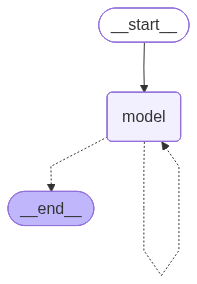

In [27]:
from langchain.agents import create_agent
# Let's define a Pydantic class
class ContactInfo(BaseModel):
    """Contact information for a person."""
    name: str = Field(description="Fullname of the person")
    email: str = Field(description="Peron's email address")
    phone: str = Field(description="Person's phone number")

agent = create_agent(model="groq:qwen/qwen3-32b", response_format=ContactInfo)
agent

In [28]:
result = agent.invoke({
    "messages": [{"role": "user", "content": "Extract content information from John Doe, john@example.com, (555) 123-4678"}]
})
result["structured_response"]

ContactInfo(name='John Doe', email='john@example.com', phone='(555) 123-4678')

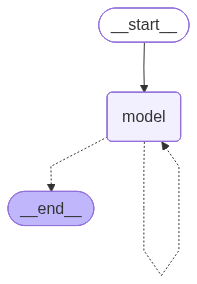

In [29]:
### Dataclass
from dataclasses import dataclass
@dataclass
class ContactInfo:
    """Contact information for a person."""
    name: str = Field(description="Fullname of the person")
    email: str = Field(description="Peron's email address")
    phone: str = Field(description="Person's phone number")

agent = create_agent(model="groq:qwen/qwen3-32b", response_format=ContactInfo)
agent

In [30]:
result = agent.invoke({
    "messages": [{"role": "user", "content": "Extract content information from John Doe, john@example.com, (555) 123-4678"}]
})
result["structured_response"]

ContactInfo(name='John Doe', email='john@example.com', phone='(555) 123-4678')